# Bank Marketing 分群教學：K-means 與 PCA

1. 讀取與檢視資料  
2. 選擇數值型特徵  
3. 標準化  
4. PCA 二維視覺化  
5. K-means 分群  
6. 使用 Silhouette Score 評估分群品質  
7. 解讀每一群的特徵差異


| 欄位名稱 | 中文說明 | 原始型態 | 資料角色 | 內容說明 | NaN 缺漏值 | 特殊未知值 | 建模時的處理建議 |
|---|---|---|---|---|---:|---:|---|
| `age` | 年齡 | `int64` | 數值特徵 | 客戶年齡 | 0 | 0 | 可直接作為特徵；若使用 KNN、SVM、Logistic Regression 等模型，可考慮標準化 |
| `job` | 職業類型 | `object` | 類別特徵 | 客戶職業，例如 management、blue-collar、technician 等 | 0 | 288 | 需要類別編碼；`unknown` 可視為未知類別或缺漏值 |
| `marital` | 婚姻狀態 | `object` | 類別特徵 | married、single、divorced | 0 | 0 | 需要類別編碼 |
| `education` | 教育程度 | `object` | 類別特徵 | primary、secondary、tertiary、unknown | 0 | 1,857 | 需要類別編碼；`unknown` 可視為未知類別或缺漏值 |
| `default` | 是否有信用違約 | `object` | 二元類別特徵 | yes、no | 0 | 0 | 可轉成 0/1 或使用 one-hot encoding |
| `balance` | 年平均帳戶餘額 | `int64` | 數值特徵 | 客戶帳戶年平均餘額，單位通常為歐元 | 0 | 0 | 可直接使用；數值範圍差異大時建議標準化 |
| `housing` | 是否有房貸 | `object` | 二元類別特徵 | yes、no | 0 | 0 | 可轉成 0/1 或使用 one-hot encoding |
| `loan` | 是否有個人貸款 | `object` | 二元類別特徵 | yes、no | 0 | 0 | 可轉成 0/1 或使用 one-hot encoding |
| `contact` | 聯絡方式 | `object` | 類別特徵 | cellular、telephone、unknown | 0 | 13,020 | 需要類別編碼；`unknown` 數量不少，教學時可保留為一個類別 |
| `day` | 最近一次聯絡日期 | `int64` | 數值 / 日期相關特徵 | 最近一次聯絡發生在該月第幾天 | 0 | 0 | 可直接使用；但它其實是日期資訊，不一定有線性關係 |
| `month` | 最近一次聯絡月份 | `object` | 類別 / 日期相關特徵 | jan、feb、mar、...、dec | 0 | 0 | 建議做類別編碼 |
| `duration` | 最近一次聯絡通話秒數 | `int64` | 數值特徵 | 最近一次電話通話時間，單位為秒 | 0 | 0 | 預測力通常很強；但若要做真實的事前預測，可能不應使用 |
| `campaign` | 本次活動聯絡次數 | `int64` | 數值特徵 | 此行銷活動期間，對該客戶聯絡的次數，包含最後一次聯絡 | 0 | 0 | 可直接使用 |
| `pdays` | 上次活動後間隔天數 | `int64` | 數值特徵 | 距離上次行銷活動聯絡經過幾天；`-1` 表示之前沒有被聯絡過 | 0 | 0 | 可直接使用；也可額外建立「是否曾被聯絡」特徵 |
| `previous` | 過去活動聯絡次數 | `int64` | 數值特徵 | 在本次活動之前，曾經聯絡該客戶的次數 | 0 | 0 | 可直接使用 |
| `poutcome` | 過去行銷活動結果 | `object` | 類別特徵 | unknown、failure、other、success | 0 | 36,959 | 需要類別編碼；`unknown` 數量很多，通常可保留為一個類別 |
| `y` | 是否申購定期存款 | `object` | 目標欄位 | yes、no | 0 | 0 | 二元分類目標欄位，通常轉成 0/1 |

In [1]:
# ============================================================
# 1. 匯入套件與讀取資料
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# bank-full.csv 使用分號 ; 作為欄位分隔符號
# 使用時請確認 bank-full.csv 與這個 notebook 放在同一個資料夾
bank_data = pd.read_csv("./bank-full.csv", sep=";")

print("完整資料筆數與欄位數：")
print(bank_data.shape)

print()
print("前 5 筆資料：")
display(bank_data.head())

完整資料筆數與欄位數：
(45211, 17)

前 5 筆資料：


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


欄位型態：
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


None

每個欄位的遺漏值數量：


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

y 欄位分布：


y
no     39922
yes     5289
Name: count, dtype: int64

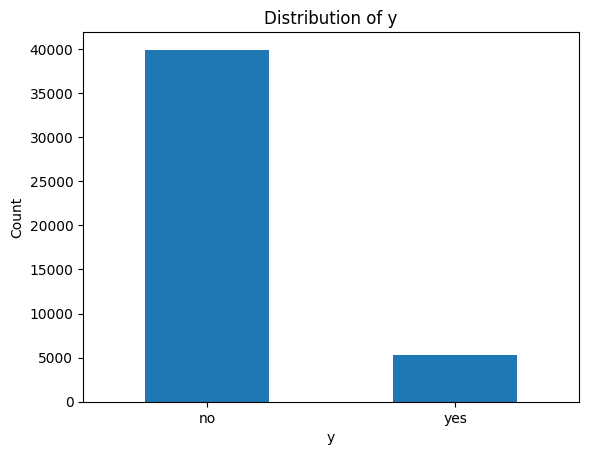

In [2]:
# ============================================================
# 2. 初步檢視資料：欄位型態、遺漏值、y 欄位分布
# ============================================================

print("欄位型態：")
display(bank_data.info())

print("每個欄位的遺漏值數量：")
display(bank_data.isnull().sum())

print("y 欄位分布：")
display(bank_data["y"].value_counts())

# 視覺化 y 欄位分布
bank_data["y"].value_counts().plot(kind="bar")
plt.title("Distribution of y")
plt.xlabel("y")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [3]:
# ============================================================
# 3. 抽樣、選擇數值型特徵、標準化
# ============================================================

# bank-full 資料筆數較多。為了讓上課示範執行速度穩定，
# 這裡抽樣 5000 筆做 PCA、K-means 與 Silhouette Score。
model_data = bank_data.sample(n=5000, random_state=0).copy()

# K-means 和 PCA 都需要數值型資料。
# 為了讓範例簡單，本 notebook 先只使用原本就是數值型的欄位。
numeric_features = model_data.select_dtypes(include=["int64", "float64"]).columns

print("本範例使用的數值型特徵：")
for feature_name in numeric_features:
    print("-", feature_name)

X = model_data.loc[:, numeric_features].copy()

# K-means 和 PCA 都會受到欄位尺度影響，所以這裡需要標準化。
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_features)

print()
print("標準化後的前 5 筆資料：")
display(X_scaled_df.head())

本範例使用的數值型特徵：
- age
- balance
- day
- duration
- campaign
- pdays
- previous

標準化後的前 5 筆資料：


,age,balance,day,duration,campaign,pdays,previous
0,-0.374354,0.033010,-0.700116,-0.672386,3.978656,-0.407397,-0.316001
1,-0.468688,-0.540560,-0.215758,3.365230,-0.600904,-0.407397,-0.316001
2,0.568984,-0.593552,-0.942296,-0.047419,0.707542,-0.407397,-0.316001
3,1.512322,-0.279405,-0.579027,-0.614824,1.361765,1.497487,0.849194
4,-0.751690,-0.593552,-0.215758,0.318515,-0.273792,-0.407397,-0.316001


PCA 解釋變異比例：
PC1: 0.2294
PC2: 0.1675
PC1 + PC2: 0.3969


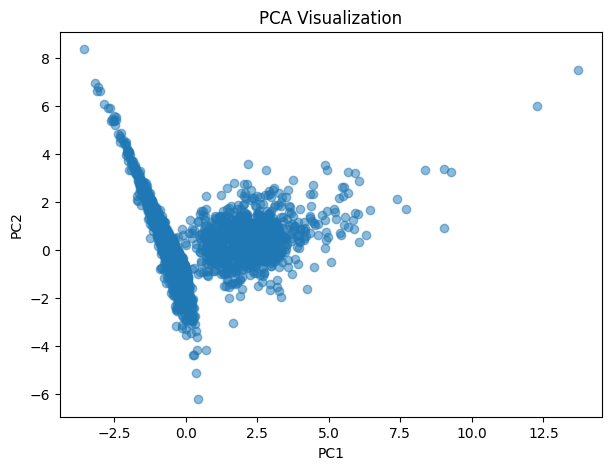

In [4]:
# ============================================================
# 4. PCA：把多個數值特徵降到 2 維，方便視覺化
# ============================================================

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame()
pca_df["PC1"] = X_pca[:, 0]
pca_df["PC2"] = X_pca[:, 1]
pca_df["y"] = model_data["y"].values

print("PCA 解釋變異比例：")
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))
print("PC1 + PC2:", round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(7, 5))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.5)
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [5]:
# ============================================================
# 5. K-means 分群：建立一個代表性的非監督式學習模型
# ============================================================

# 為了讓教學簡單，這裡先指定分成 3 群。
# 在實務上，可以搭配 Elbow Method 或 Silhouette Score 嘗試不同的 K。
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

model_data["cluster"] = cluster_labels
pca_df["cluster"] = cluster_labels

print("每一群的資料筆數：")
display(model_data["cluster"].value_counts().sort_index())

# Silhouette Score 是分群常用評估指標之一。
# 分數越高，通常代表同群資料越接近、不同群資料越分開。
silhouette = silhouette_score(
    X_scaled,
    cluster_labels,
    sample_size=2000,
    random_state=0
)

print("Silhouette Score:", round(silhouette, 4))

每一群的資料筆數：


cluster
0    2005
1    2239
2     756
Name: count, dtype: int64

Silhouette Score: 0.1843


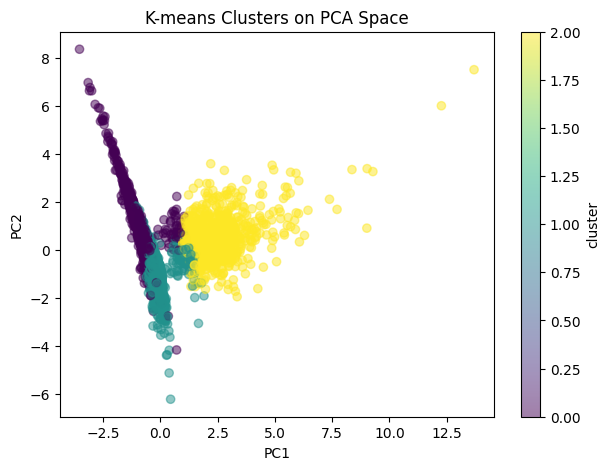

In [6]:
# ============================================================
# 6. 使用 PCA 平面視覺化 K-means 分群結果
# ============================================================

plt.figure(figsize=(7, 5))
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    alpha=0.5
)
plt.title("K-means Clusters on PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster")
plt.show()

各群的數值型特徵平均值：


,age,balance,day,duration,campaign,pdays,previous
cluster,,,,,,,
0,40.16,1388.11,23.20,203.26,3.90,2.04,0.04
1,41.83,1160.74,9.70,297.41,2.12,2.38,0.05
2,40.58,1529.65,14.12,263.54,2.13,248.27,3.32



各群中 y 的比例：


y,no,yes
cluster,,
0,0.940,0.060
1,0.871,0.129
2,0.779,0.221


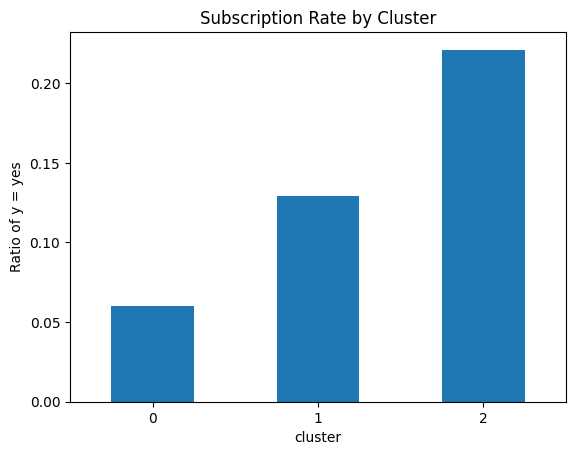

In [7]:
# ============================================================
# 7. 解讀分群結果：觀察各群的原始特徵平均值與 y 比例
# ============================================================

# 這裡使用原始尺度的資料解讀群集，會比看標準化後的數值更直覺。
cluster_profile = model_data.groupby("cluster")[numeric_features].mean().round(2)

print("各群的數值型特徵平均值：")
display(cluster_profile)

print()
print("各群中 y 的比例：")
y_ratio_by_cluster = pd.crosstab(
    model_data["cluster"],
    model_data["y"],
    normalize="index"
).round(3)
display(y_ratio_by_cluster)

# 將每一群的 yes 比例畫出來，方便觀察哪些群比較容易定存。
# 注意：y 沒有參與 K-means 訓練，這裡只是用來輔助解讀分群結果。
if "yes" in y_ratio_by_cluster.columns:
    y_ratio_by_cluster["yes"].plot(kind="bar")
    plt.title("Subscription Rate by Cluster")
    plt.xlabel("cluster")
    plt.ylabel("Ratio of y = yes")
    plt.xticks(rotation=0)
    plt.show()